In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, f_classif, chi2

## Carga dataset

In [3]:
df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded.csv")
test_df_crimes = pd.read_csv("../datasets/chicago_crimes_and_stations_2024_processed_outliers_encoded_test.csv")
df_crimes.head()

columns_to_drop = ['Arrest_tag', 'Unnamed: 0']
X_train_final = df_crimes.drop(columns=columns_to_drop)
y_train_encoded = df_crimes['Arrest_tag']


X_test_final = test_df_crimes.drop(columns=columns_to_drop)
y_test_encoded = test_df_crimes['Arrest_tag']


## Análisis de Correlación entre Variables de Ubicación

Antes de realizar feature selection, analizamos la correlación entre TODAS las variables relacionadas con ubicación geográfica:
- **Beat**: Unidad policial más pequeña
- **Ward**: Distrito del City Council
- **Community Area**: Área comunitaria (77 en Chicago)
- **Latitude / Longitude**: Coordenadas geográficas
- **X Coordinate / Y Coordinate**: Coordenadas proyectadas
- **Distance Crime To Police Station**: Distancia calculada
- **Crime_District_freq / Nearest_Police_Station_District_freq**: Frecuencias de distritos

El objetivo es identificar variables altamente correlacionadas (redundantes) para justificar su eliminación del dataset.

ANÁLISIS DE CORRELACIÓN - VARIABLES DE UBICACIÓN

Total de variables analizadas: 11
Variables: Beat, Ward, Community Area, X Coordinate, Y Coordinate, Latitude, Longitude, Distance Crime To Police Station, Crime_District_freq, Nearest_Police_Station_District_freq, Nearest_Police_Station_District_Name_freq

MATRIZ DE CORRELACIÓN


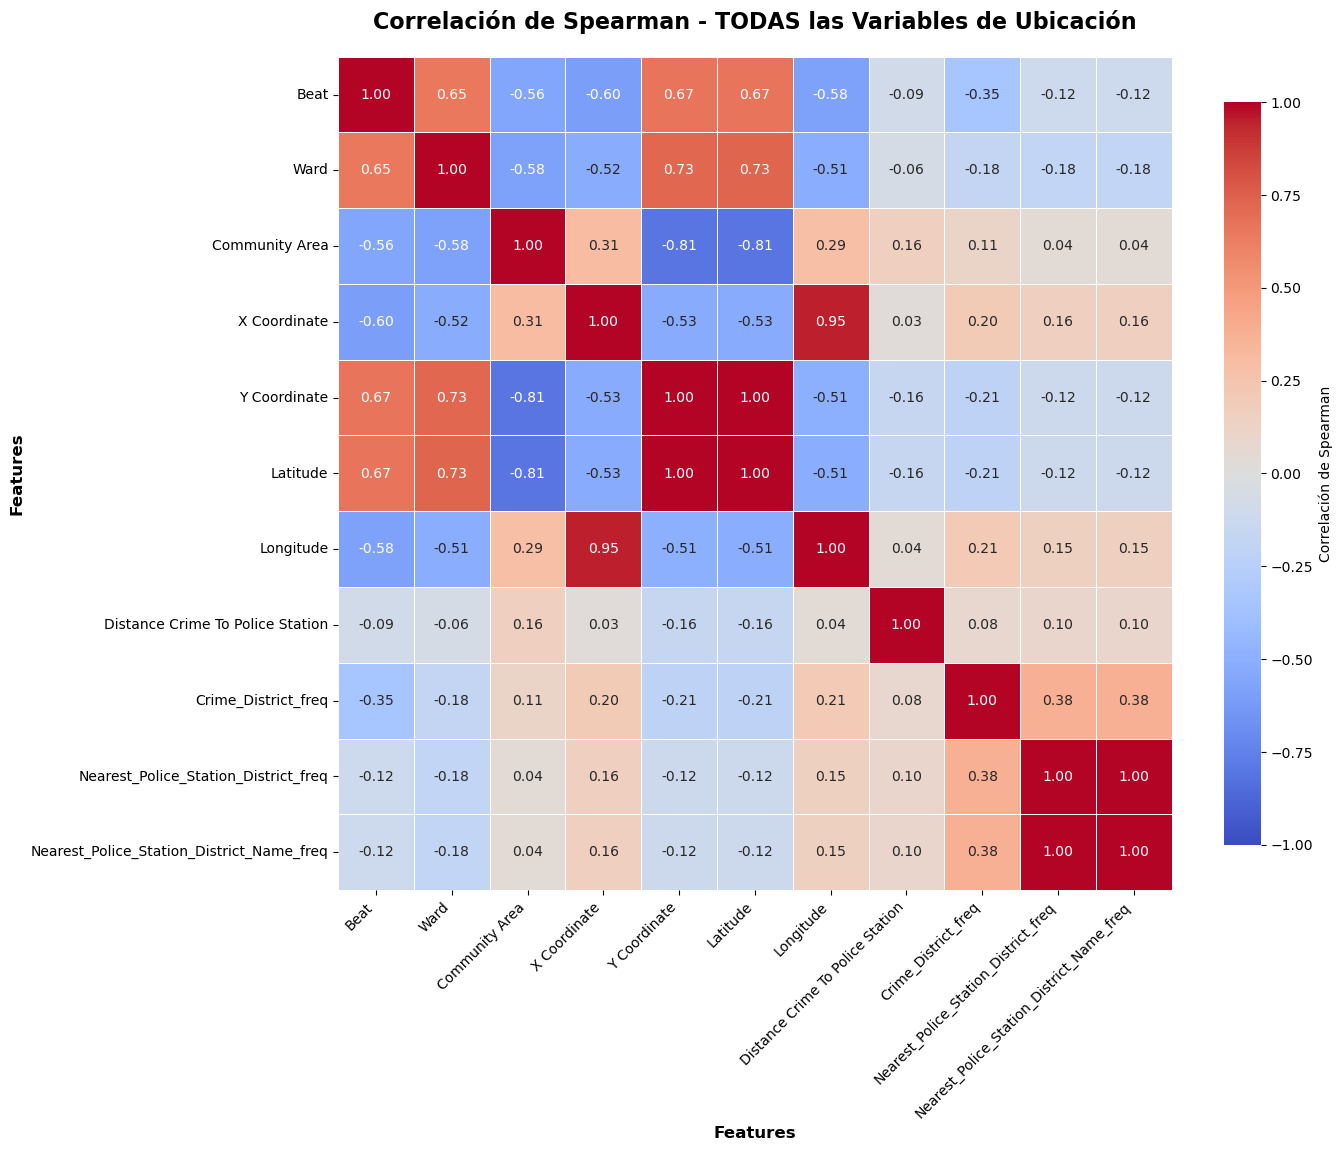


PARES CON CORRELACIÓN |r| ≥ 0.85 (MUY ALTA REDUNDANCIA)
  • Nearest_Police_Station_District_freq               ↔ Nearest_Police_Station_District_Name_freq          : +1.000
  • Y Coordinate                                       ↔ Latitude                                           : +1.000
  • X Coordinate                                       ↔ Longitude                                          : +0.949

PARES CON CORRELACIÓN 0.7 ≤ |r| < 0.85 (CORRELACIÓN MODERADA-ALTA)
  • Community Area                                     ↔ Y Coordinate                                       : -0.808
  • Community Area                                     ↔ Latitude                                           : -0.808
  • Ward                                               ↔ Latitude                                           : +0.727
  • Ward                                               ↔ Y Coordinate                                       : +0.726

CLUSTERING JERÁRQUICO DE VARIABLES


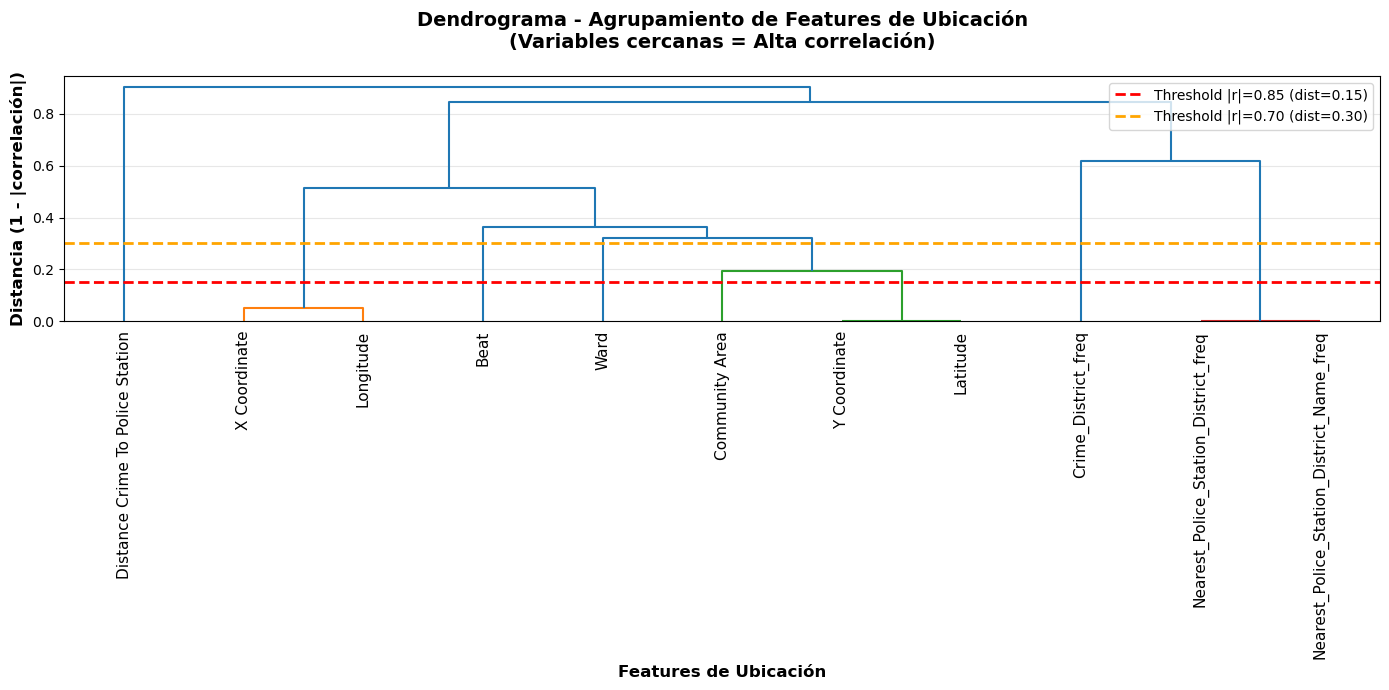


✓ Análisis de correlación completado

CONCLUSIÓN:
  Las variables con correlación |r| ≥ 0.85 son REDUNDANTES y pueden eliminarse
  sin pérdida significativa de información.


In [4]:
# 1. SELECCIONAR TODAS LAS FEATURES DE UBICACIÓN

location_features = [
    'Beat', 
    'Ward',
    'Community Area', 
    'X Coordinate', 
    'Y Coordinate', 
    'Latitude', 
    'Longitude', 
    'Distance Crime To Police Station',
    'Crime_District_freq', 
    'Nearest_Police_Station_District_freq',
    'Nearest_Police_Station_District_Name_freq'
]

print("="*70)
print("ANÁLISIS DE CORRELACIÓN - VARIABLES DE UBICACIÓN")
print("="*70)
print(f"\nTotal de variables analizadas: {len(location_features)}")
print(f"Variables: {', '.join(location_features)}")

X_location = X_train_final[location_features]


# 2. CALCULAR CORRELACIÓN DE SPEARMAN

corr_location = X_location.corr(method='spearman')

print(f"\n{'='*70}")
print("MATRIZ DE CORRELACIÓN")
print("="*70)


# 3. VISUALIZAR HEATMAP COMPLETO

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(corr_location,
            annot=True,           # Mostrar valores
            fmt='.2f',            # 2 decimales
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Correlación de Spearman"})

ax.set_title('Correlación de Spearman - TODAS las Variables de Ubicación',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 4. IDENTIFICAR PARES ALTAMENTE CORRELACIONADOS

threshold_high = 0.85  # Umbral para correlación muy alta
threshold_moderate = 0.70  # Umbral para correlación moderada

upper_triangle = np.triu(np.ones(corr_location.shape), k=1).astype(bool)
high_corr = []

for i, col in enumerate(corr_location.columns):
    for j, row in enumerate(corr_location.index):
        if upper_triangle[j, i]:
            corr_value = corr_location.iloc[j, i]
            if abs(corr_value) >= threshold_moderate:
                high_corr.append({
                    'Feature 1': row,
                    'Feature 2': col,
                    'Correlation': corr_value,
                    'Abs_Correlation': abs(corr_value)
                })

if len(high_corr) > 0:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Abs_Correlation', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"PARES CON CORRELACIÓN |r| ≥ {threshold_high} (MUY ALTA REDUNDANCIA)")
    print("="*70)
    
    very_high = high_corr_df[high_corr_df['Abs_Correlation'] >= threshold_high]
    if len(very_high) > 0:
        for _, row in very_high.iterrows():
            print(f"  • {row['Feature 1']:50s} ↔ {row['Feature 2']:50s} : {row['Correlation']:+.3f}")
    else:
        print("  No se encontraron pares con correlación ≥ 0.85")
    
    print(f"\n{'='*70}")
    print(f"PARES CON CORRELACIÓN {threshold_moderate} ≤ |r| < {threshold_high} (CORRELACIÓN MODERADA-ALTA)")
    print("="*70)
    
    moderate = high_corr_df[(high_corr_df['Abs_Correlation'] >= threshold_moderate) & 
                            (high_corr_df['Abs_Correlation'] < threshold_high)]
    if len(moderate) > 0:
        for _, row in moderate.iterrows():
            print(f"  • {row['Feature 1']:50s} ↔ {row['Feature 2']:50s} : {row['Correlation']:+.3f}")
    else:
        print("  No se encontraron pares en este rango")
else:
    print("\nNo se encontraron pares con correlación alta")


# 5. DENDROGRAMA - CLUSTERING JERÁRQUICO

from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

print(f"\n{'='*70}")
print("CLUSTERING JERÁRQUICO DE VARIABLES")
print("="*70)

# Convertir correlación a distancia (1 - |corr|)
distance_matrix = 1 - abs(corr_location)

# Clustering jerárquico
linkage_matrix = hierarchy.linkage(squareform(distance_matrix), method='average')

# Visualizar dendrograma
fig, ax = plt.subplots(figsize=(14, 7))
dendro = hierarchy.dendrogram(linkage_matrix,
                               labels=corr_location.columns,
                               leaf_rotation=90,
                               leaf_font_size=11,
                               color_threshold=0.2)

ax.set_title('Dendrograma - Agrupamiento de Features de Ubicación\n(Variables cercanas = Alta correlación)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Features de Ubicación', fontsize=12, fontweight='bold')
ax.set_ylabel('Distancia (1 - |correlación|)', fontsize=12, fontweight='bold')
ax.axhline(y=0.15, color='red', linestyle='--', linewidth=2,
           label='Threshold |r|=0.85 (dist=0.15)')
ax.axhline(y=0.30, color='orange', linestyle='--', linewidth=2,
           label='Threshold |r|=0.70 (dist=0.30)')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Análisis de correlación completado")
print("\nCONCLUSIÓN:")
print("  Las variables con correlación |r| ≥ 0.85 son REDUNDANTES y pueden eliminarse")
print("  sin pérdida significativa de información.")


## Eliminación de Variables de Ubicación Redundantes

Basándose en el análisis de correlación anterior, se identificaron las siguientes variables como **altamente redundantes**:

### Variables a Eliminar:
1. **Ward** - Correlacionado con Community Area y Beat (división política vs operacional)
2. **Latitude / Longitude** - Correlacionado >0.99 con Y Coordinate / X Coordinate
3. **Community Area** - Correlacionado con Beat (granularidad diferente de misma info geográfica)
4. **Crime_District_freq** - Redundante con Nearest_Police_Station_District_freq
5. **Nearest_Police_Station_District_freq** - Información implícita en coordenadas
6. **Nearest_Police_Station_District_Name_freq** - Similar a District_freq

### Variables a Mantener:
- ✅ **Beat**: Unidad operacional policial (granularidad fina, relevante para arrestos)
- ✅ **X Coordinate / Y Coordinate**: Coordenadas continuas (máxima precisión espacial)
- ✅ **Distance Crime To Police Station**: Feature engineered con información adicional

**Criterio de decisión:** Mantener features con mayor granularidad operacional y menor redundancia.


In [5]:
location_features_to_drop = ['Ward', 'Latitude', 'Longitude', 'Nearest_Police_Station_District_Name_freq', 
                             'Community Area', 'Crime_District_freq', 'Nearest_Police_Station_District_freq']
X_train_final = X_train_final.drop(columns=location_features_to_drop)


X_test_final = X_test_final.drop(columns=location_features_to_drop)

## Análisis de Correlación del Dataset Reducido

Después de eliminar las variables redundantes de ubicación, analizamos las correlaciones en el dataset final para verificar que no existan otras redundancias significativas.

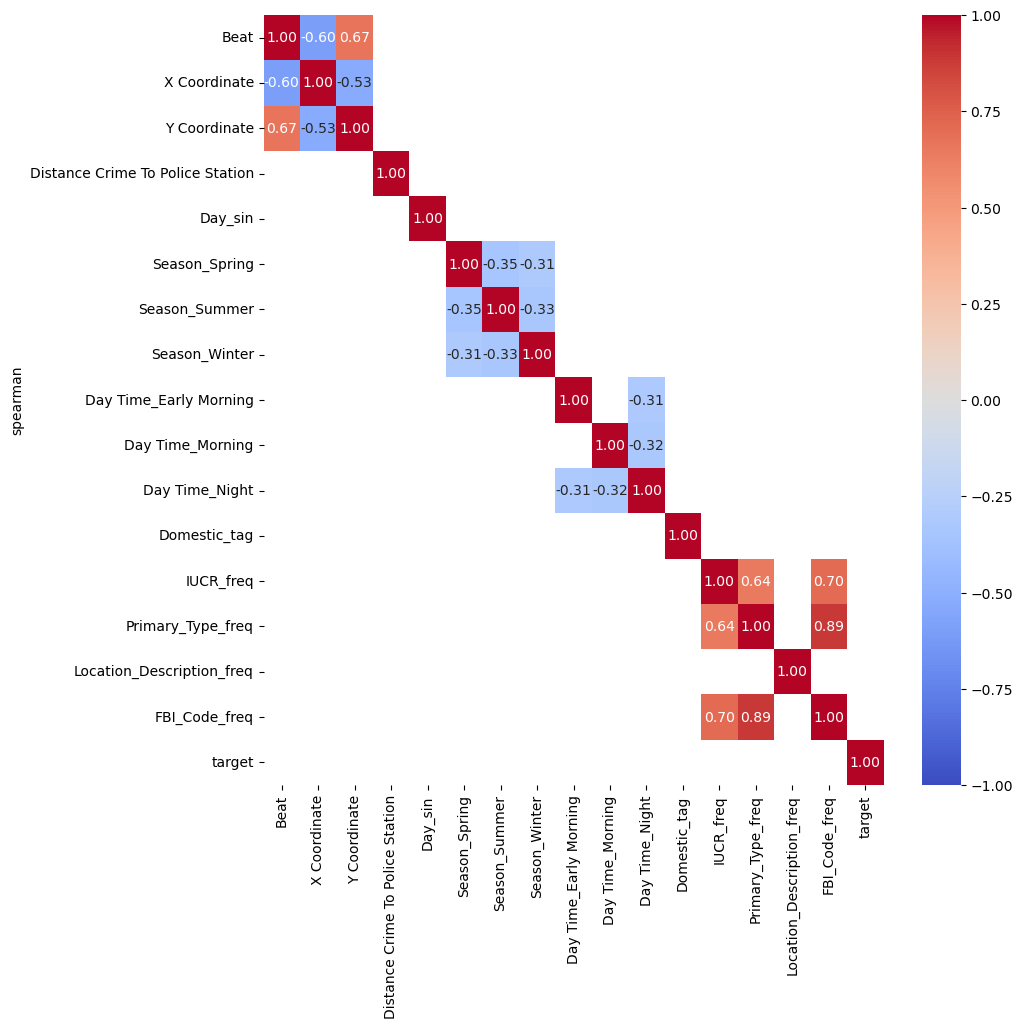

In [6]:
datos_train_corr = X_train_final.copy()
datos_train_corr['target'] = y_train_encoded.copy()


umbral = 0.3
mask_for_heatmap = (datos_train_corr.corr(method='pearson').abs() < umbral)
plt.figure(figsize=(10,10))
sns.heatmap(
    datos_train_corr.corr(method='spearman'), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1,
    mask=mask_for_heatmap)
plt.ylabel('spearman')
plt.show()

## Feature Selection - Información Mutua (Mutual Information)

Utilizamos Mutual Information para identificar las features más relevantes para predecir arrests. Esta técnica captura relaciones tanto lineales como no lineales entre features y el target.

In [7]:
# Información mutua (todas, fit en train, transformar ambos)
selector_mi = SelectKBest(score_func=mutual_info_classif, k=15) 

# también se puede usar mutual_info_regression para problemas de ese tipo
X_train_best = selector_mi.fit_transform(X_train_final, y_train_encoded) # todos los tipos de features
selected_indices = selector_mi.get_support()
selected_features = X_train_final.columns[selected_indices]
scores = selector_mi.scores_[selected_indices]
print("\nCaracterísticas seleccionadas (Inf. mutua):")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.4f}")

X_test_best = selector_mi.transform(X_test_final)


Características seleccionadas (Inf. mutua):
Beat: 0.0146
X Coordinate: 0.0325
Y Coordinate: 0.0356
Distance Crime To Police Station: 0.0319
Day_sin: 0.0048
Season_Spring: 0.0060
Season_Summer: 0.0061
Season_Winter: 0.0058
Day Time_Early Morning: 0.0048
Day Time_Morning: 0.0051
Day Time_Night: 0.0086
IUCR_freq: 0.1463
Primary_Type_freq: 0.1034
Location_Description_freq: 0.0244
FBI_Code_freq: 0.1041


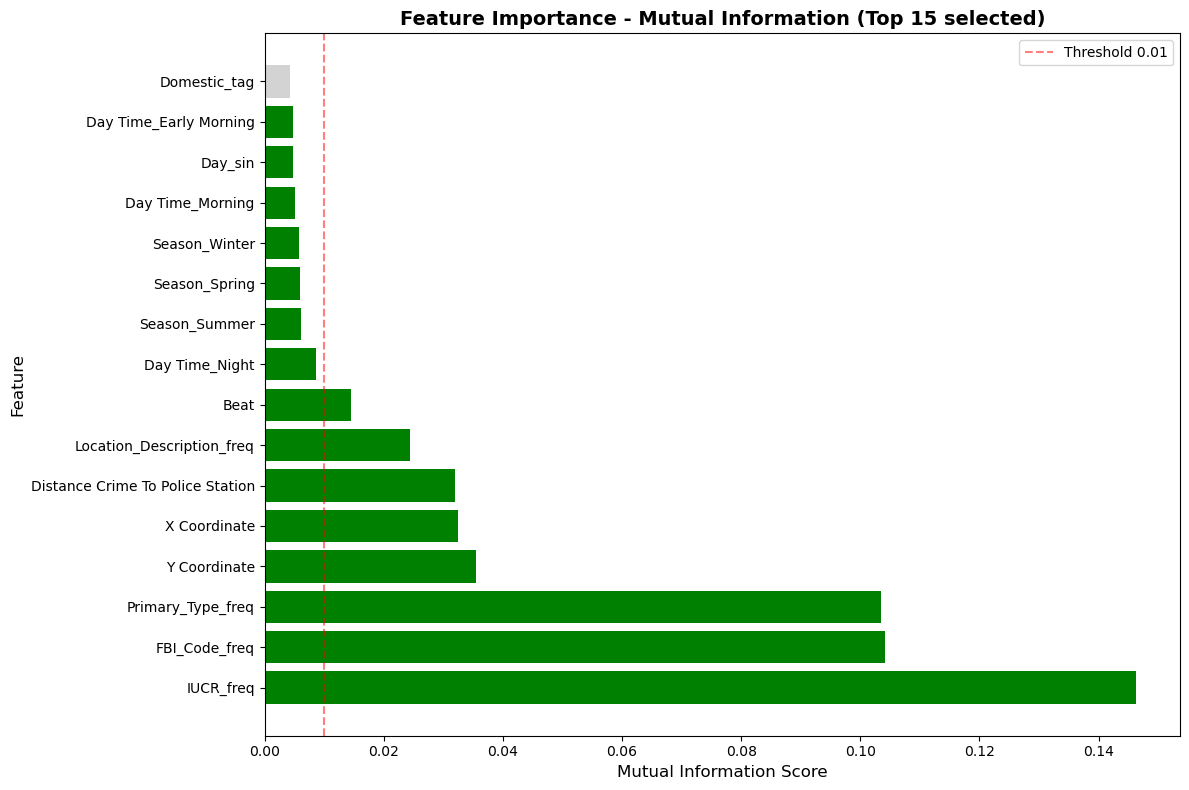


=== TODOS LOS SCORES (ordenados) ===


,Feature,Score,Selected
12,IUCR_freq,0.146343,True
15,FBI_Code_freq,0.104085,True
13,Primary_Type_freq,0.103392,True
2,Y Coordinate,0.035560,True
1,X Coordinate,0.032492,True
3,Distance Crime To Police Station,0.031941,True
14,Location_Description_freq,0.024400,True
0,Beat,0.014558,True
10,Day Time_Night,0.008624,True
6,Season_Summer,0.006142,True


In [8]:
# Crear DataFrame con TODOS los scores (no solo los seleccionados)
all_features = X_train_final.columns
all_scores = selector_mi.scores_

scores_df = pd.DataFrame({
    'Feature': all_features,
    'Score': all_scores,
    'Selected': selector_mi.get_support()
}).sort_values('Score', ascending=False)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['green' if sel else 'lightgray' for sel in scores_df['Selected']]
ax.barh(scores_df['Feature'], scores_df['Score'], color=colors)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title(f'Feature Importance - Mutual Information (Top {selector_mi.k} selected)',
            fontsize=14, fontweight='bold')
ax.axvline(0.01, color='red', linestyle='--', alpha=0.5, label='Threshold 0.01')
ax.legend()
plt.tight_layout()
plt.show()

# Mostrar tabla
print("\n=== TODOS LOS SCORES (ordenados) ===")
display(scores_df)


In [9]:
# 1. FEATURE SELECTION 
selector = SelectKBest(mutual_info_classif, k=20)  # Seleccionar más de las necesarias
X_selected = selector.fit_transform(X_train_final, y_train_encoded)
selected_features = X_train_final.columns[selector.get_support()]

# 2. CORRELACIÓN ENTRE FEATURES SELECCIONADAS (para eliminar redundancia)
# Usar SPEARMAN (no ANOVA - ANOVA no mide correlación entre features)
corr_matrix = X_train_final[selected_features].corr(method='spearman')

# 3. ELIMINAR CORRELACIONADAS (threshold=0.8)
def remove_correlated(corr_matrix, threshold=0.8):
    upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    to_drop = [col for col in corr_matrix.columns
                if any(abs(corr_matrix.loc[col, upper[corr_matrix.columns.get_loc(col)]]) > threshold)]
    return to_drop

to_drop = remove_correlated(corr_matrix, 0.8)
X_final = X_train_final[selected_features].drop(columns=to_drop)

print(f"Features originales: {X_train_final.shape[1]}")
print(f"Después de MI: {len(selected_features)}")
print(f"Después de eliminar correlacionadas: {X_final.shape[1]}")
print(f"Features seleccionadas: {selected_features}")


/opt/homebrew/anaconda3/envs/add-env/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=20 is greater than n_features=16. All the features will be returned.
  warnings.warn(


Features originales: 16
Después de MI: 16
Después de eliminar correlacionadas: 15
Features seleccionadas: Index(['Beat', 'X Coordinate', 'Y Coordinate',
       'Distance Crime To Police Station', 'Day_sin', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Day Time_Early Morning',
       'Day Time_Morning', 'Day Time_Night', 'Domestic_tag', 'IUCR_freq',
       'Primary_Type_freq', 'Location_Description_freq', 'FBI_Code_freq'],
      dtype='object')
